<div style="text-align: center;" markdown="1"> ADRL  Assignment 2  - VAE</div>
<div style="text-align: center;" markdown="1"> Team: Shivam Padmani, Saurav Ranjan Saraf </div>


#### Question 1: Vanilla VAE with MSE for conditional likelihood

## Table of Results

| Sample Size of \( z \) | MSE Loss (Final) | KL Divergence (Final) | Combined Loss (Final) | FID Score | Notes |
|------------------------|-------------------|-----------------------|-----------------------|-----------|-------|
| 128          |    0.85226 |        0.12604              |          0.97830               |     202    |       |



In [6]:
model_name = 'vanilla_vae_animals'
import os
import tqdm
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.utils import save_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
# Data loading
path = os.path.join(os.getcwd(), 'data','augmented_animals')

MEAN = torch.tensor([0.50869316, 0.50057036, 0.44047505])
STD = torch.tensor([0.20191325, 0.19737212, 0.20100889])

image_size = 128
batch_size = 128
workers = 6
n_channels = 3
latent_dim = 256
lr = 0.0002
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_data = ImageFolder(path, transform=transform)
loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=workers)

classes = train_data.classes

In [8]:
# # Show some training images
# for image, _ in loader:
#     print("Image tensor shape:", image.shape)
#     plt.figure(figsize=(8, 8))
#     plt.axis("off")
#     plt.title("Training Images")
#     image = (image * STD[:, None, None] + MEAN[:, None, None]).clamp(0, 1)
#     plt.imshow(make_grid(image[:64], nrow=8).permute(1, 2, 0).cpu().numpy())
#     break

In [9]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim
        self.input_dim = n_channels
        self.output_dim = latent_dim

        self.encode = nn.Sequential(
            nn.Conv2d(self.input_dim, 16, 4, 2, 1, bias=False),  # 64 x 64
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),

            nn.Conv2d(16, 32, 4, 2, 1, bias=False),  # 32 x 32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, 2, 1, bias=False),  # 16 x 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),  # 8 x 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),  # 4 x 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),  # 2 x 2
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )
        self.layer_mean = nn.Linear(512 * 2 * 2, self.output_dim)
        self.layer_var = nn.Linear(512 * 2 * 2, self.output_dim)

    def forward(self, x):
        x = self.encode(x)
        x = torch.flatten(x, start_dim=1)
        mean = self.layer_mean(x)
        var = self.layer_var(x)
        return mean, var

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.batch_size = batch_size
        self.latent_dim = latent_dim
        self.input_dim = latent_dim
        self.output_dim = n_channels

        self.fc = nn.Linear(self.input_dim, 512 * 2 * 2)
        
        self.decode = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  # 4 x 4
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  # 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  # 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),  # 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),  # 64 x 64
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(16, self.output_dim, 4, 2, 1, bias=False),  # 128 x 128
            nn.Tanh()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 512, 2, 2)
        out = self.decode(x)
        return (out + 1) / 2  # Normalize output

    
class Vanilla_VAE(nn.Module):
    def __init__(self):
        super(Vanilla_VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterization(self, mean, var):
        std = torch.exp(0.5*var) # standard deviation from log(variance)
        epsilon = torch.randn_like(std) # sampling from normal (0,1)
        return mean + std * epsilon
    
    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = self.reparameterization(mean, log_var)
        x_hat = self.decoder(z) # reconstructed image
        return x_hat, mean, log_var
            
    def sample(self, z):
        return self.decoder(z)
    
def weights_init(c):
    class_name = c.__class__.__name__
    if class_name.find("Conv") != -1:
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        # mean of Conv layer weights is taken 0.0
    elif class_name.find("BatchNorm") != -1:
        nn.init.normal_(c.weight.data, 1.0, 0.0)
        # mean of Batch Normalization layer weights is taken 0.0
        nn.init.constant_(c.bias.data, 0)
def read_epoch_count(file_path):
    with open(file_path, 'r') as file:
        return int(file.readline().strip())


###### $\text{KL}_{\text{div}} = - 0.5 \times \left( 1 + \log(\sigma^2) - \mu^2 - \sigma^2 \right)$




In [ ]:
n_epochs = 100
initial_beta = 0.0  # Start with low KL weight
final_beta = 1.0    # Final desired KL weight
anneal_steps = 1000  # Number of steps to reach final beta


vae = Vanilla_VAE().to(device)

criterion = nn.MSELoss() # Mean Squared Error Loss mentioned in question

vae.apply(weights_init)

optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

# progressbar = tqdm.tqdm(range(n_epochs), total=n_epochs, desc='Epoch')
Likelihood = []
KL_Divergence = []
Total_Loss = []
os.makedirs(f'output/{model_name}', exist_ok=True)

# epoch_file_path = os.path.join(os.getcwd(), 'epochs.txt')

epoch = 0
while True:
    # n_epochs = read_epoch_count(epoch_file_path)
    for i, (images, _) in enumerate(loader):
        images = images.to(device)
        # outputs are reconstructed images
        outputs, mean, log_var = vae(images)  # mean, var shape [batch_size, latent_dim]
        # var is diagonal elements of covariance matrix
        # Reconstruction loss
        rec_loss = criterion(outputs, images) # By default  mean of square error
        Likelihood.append(rec_loss.item())
        # KL divergence loss
        # Analytical formula for KL divergence between 1) parameters by encoder and 2) normal (0,1)
        kl_div = - 0.5 * torch.mean(1 + log_var - mean**2 - log_var.exp()) 
        KL_Divergence.append(kl_div.item())
        assert not torch.isnan(kl_div).any(), "NaN values in KL divergence"
        current_step = epoch * len(loader) + i
        param = min(final_beta, initial_beta + current_step / anneal_steps * (final_beta - initial_beta))

        # Now KL Annealing have to be done because i am getting posterior collapse
        loss = rec_loss + param * kl_div
        while kl_div.item() < 0.01*loss.item():
            kl_div *= 10
            loss = rec_loss + kl_div
        while rec_loss.item() < 0.6*loss.item():
            rec_loss *= 2
            loss = rec_loss + kl_div
        Total_Loss.append(loss.item())
        assert not torch.isnan(loss).any(), "NaN values in loss"

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if  i == len(loader) - 1 and epoch % 10 == 0:
            noise = torch.randn(100, latent_dim).to(device)  # To generate 100 images in a grid
            fake_images = vae.decoder(noise).clamp(0, 1)
            # Reshape and scale the fake images
            # fake_images = fake_images.view(fake_images.size(0), n_channels, image_size, image_size)  # Ensure shape (N, C, H, W)

            # Save the generated fake images
            save_image(fake_images, f'output/{model_name}/gen_{model_name}_{epoch}_{i}.png', nrow=10)

            # Generate reconstructed images
            rec_images, _, _ = vae.forward(images[:101]) # Forward pass for the first 100 images
            rec_images = rec_images.clamp(0, 1)
            # rec_images = rec_images.view(rec_images.size(0), n_channels, image_size, image_size)  # Ensure shape (N, C, H, W)

            # Save the reconstructed images
            save_image(rec_images, f'output/{model_name}/rec_{model_name}_{epoch}_{i}.png', nrow=10)

            print(f'Epoch [{epoch}/{n_epochs}], Step [{i}/{len(loader)}], Loss: {loss.item():.5f}, Rec Loss: {rec_loss.item():.5f}, KL Div: {kl_div.item():.5f}')
    epoch += 1
    if epoch > n_epochs:
        break
    # progressbar.set_postfix({'Reconstruction Loss': rec_loss.item(), 'KL Divergence': kl_div.item(), 'Total Loss': loss.item()})
# Save Model
torch.save(vae, f'output/{model_name}.pth')

Observations: \
MSELoss: Mean of batch by default so KL Loss should also use torch.mean instead of torch.sum \
Experienced Posterior collapse many times while training initially. \
Using Linear KL Annealing, got stable training for VAE.


##### Reconstructed Images

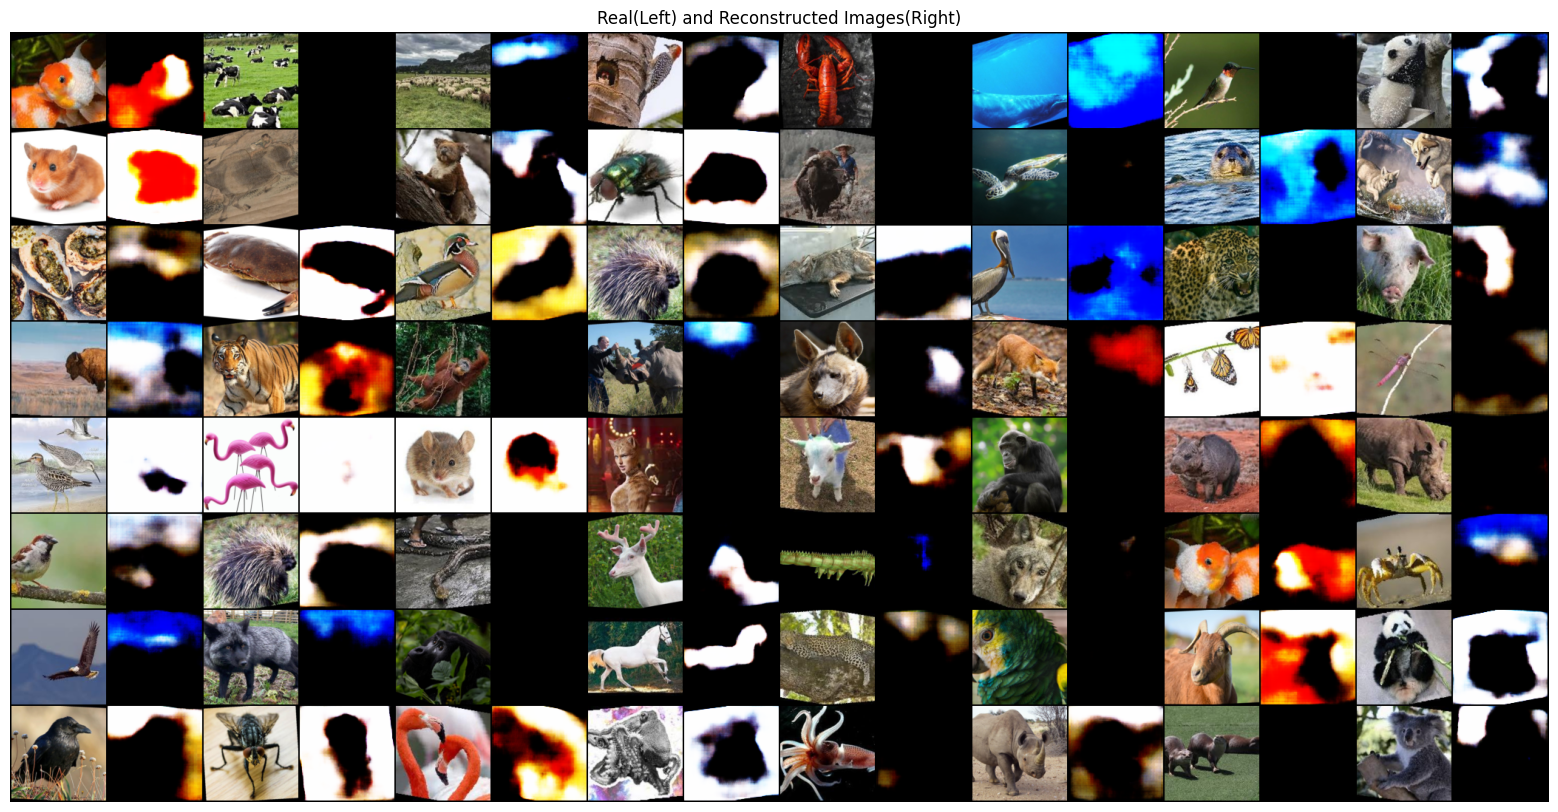

In [11]:
# Give real images to encoder and get reconstructed images from decoder
import random
# Load the VAE model
vae = torch.load(f'output/{model_name}.pth', weights_only=False)
vae.eval()
n_images = 64  # Number of images to display
img_list = []
rec_img_list = []

# Randomly select indices
indices = random.sample(range(len(train_data)), n_images)

# Process images
for idx in indices:
    img, _ = train_data[idx]
    img = img.unsqueeze(0).to(device)
    rec_img = vae(img)[0].clamp(0, 1)
    img_list.append(img.squeeze(0))
    rec_img_list.append(rec_img.squeeze(0))

# Combine real and reconstructed images
combined_images = []
for real_img, rec_img in zip(img_list, rec_img_list):
    real_img = real_img * STD[:, None, None].to(device) + MEAN[:, None, None].to(device)
    combined_images.append(real_img)
    combined_images.append(rec_img)

# Ensure all tensors are on the same device
combined_images = [img.to(device) for img in combined_images]

# Create a grid of images
combined_images = torch.stack(combined_images, dim=0)
grid_img = make_grid(combined_images, nrow=16, padding=2)

# Plot the images
plt.figure(figsize=(20, 10))  # Adjust the width and height as needed
plt.title("Real(Left) and Reconstructed Images(Right)")
plt.axis("off")
plt.imshow(grid_img.cpu().clamp(0, 1).permute(1, 2, 0).numpy())
plt.show()

#### Generated Images

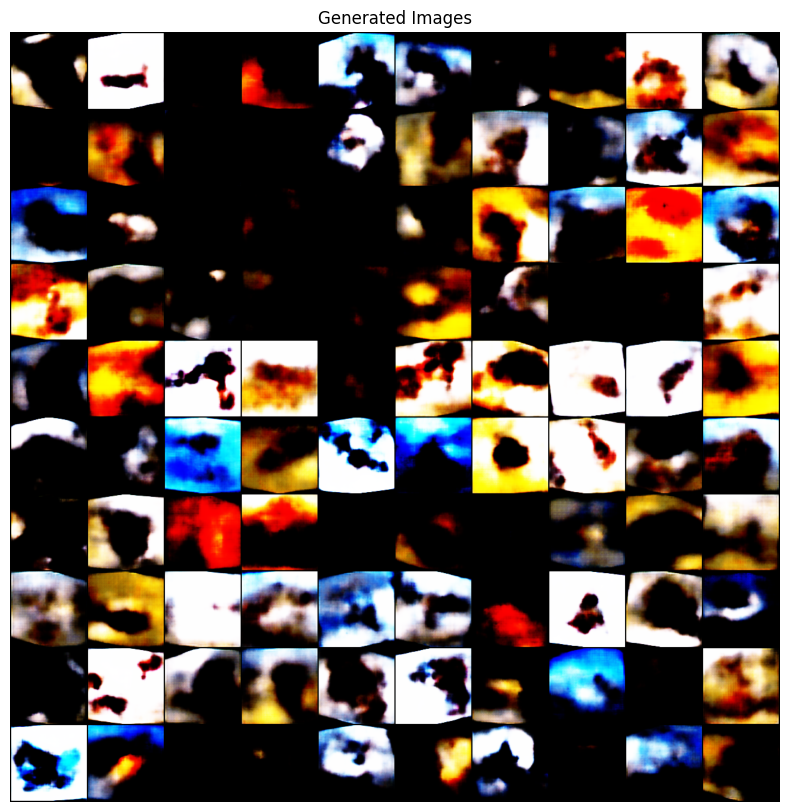

In [12]:
# Give real images to encoder and get reconstructed images from decoder
vae = torch.load(f'output/{model_name}.pth',weights_only=False)
vae.eval()
n_images = 100
img_list = []
for i in range(n_images):
    noise = torch.randn(1, latent_dim).to(device)
    rec_img = vae.decoder(noise).clamp(0, 1)
    img_list.append(rec_img)
img_list = torch.cat(img_list, dim=0)
plt.figure(figsize=(10,10))
plt.title("Generated Images")
plt.axis('off')
plt.imshow(make_grid(img_list,padding=2, nrow=10).cpu().permute(1, 2, 0))
plt.show()

#### Loss curves for likelihood, KL and Total loss

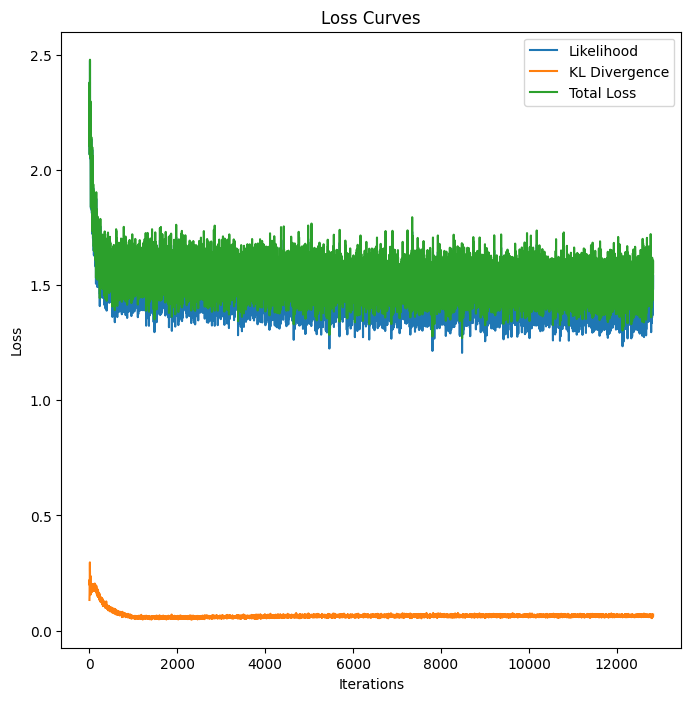

In [13]:
# Loss Curves for likelihood, KL divergence and Total loss

plt.figure(figsize=(8, 8))
plt.plot(Likelihood, label='Likelihood')
plt.plot(KL_Divergence, label='KL Divergence')
plt.plot(Total_Loss, label='Total Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

#### FID computation for generated images

In [ ]:
# FID Computation for 1000 images generated using VAE
vae = torch.load(f'output/{model_name}.pth',weights_only=False).to(device)
vae.eval()
with torch.no_grad():
    fake_images = []
        # sample 1000 images from the noise
    for i in range(1000):
        noise = torch.randn(1, latent_dim).to(device)
        img = vae.decoder(noise).view(1,3,128,128).clamp(0, 1)
        fake_images.append(img)
    fake_images = torch.cat(fake_images, dim=0)
    # 1000 real fake_images in tensor format
    real_images = []
    # sample 1000 images from the training set
    for i in range(1000):
        img = train_data[i][0].clamp(0,1).to(device)
        real_images.append(img)

    ! pip install pytorch-fid
    from pytorch_fid import fid_score
    from torcheval.metrics import FrechetInceptionDistance

    fid_metric = FrechetInceptionDistance()
    real_images = torch.stack(real_images)
    fake_images = torch.tensor(fake_images)
    # Update the FID metric with real and generated images
    fid_metric.update(real_images, is_real=True)
    fid_metric.update(fake_images, is_real=False)

    # Compute the FID score
    fid_score = fid_metric.compute()
    print(f'FID Score for {n_images} images: {fid_score}')
